# business problem

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load dataset

In [5]:
path=r"https://drive.google.com/uc?export=download&id=13ZTYmL3E8S0nz-UKl4aaTZJaI3DVBGHM"
df=pd.read_csv(path)

In [6]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [7]:
df.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [9]:
df.shape

(200, 2)

# discover and visualize the data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [11]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


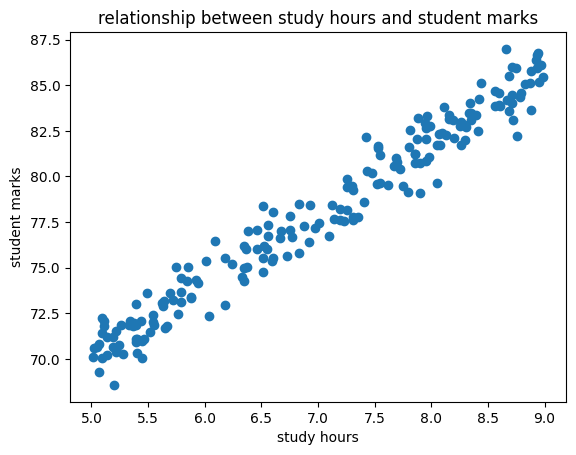

In [12]:
plt.scatter(x=df.study_hours , y=df.student_marks)
plt.xlabel("study hours")
plt.ylabel("student marks")
plt.title("relationship between study hours and student marks")
plt.show()


# prepare the data for the machine learning model

In [13]:
df.isnull().sum()

,0
study_hours,5
student_marks,0


In [14]:
df.mean()

,0
study_hours,6.995949
student_marks,77.933750


In [16]:
df2=df.fillna(df.mean())

In [19]:
df2.isnull().sum()

,0
study_hours,0
student_marks,0


In [20]:
df2.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


# split the data

In [30]:
x=df2.drop("student_marks", axis=1)
y=df2.drop("study_hours", axis=1)
print("shape of x" ,x.shape)
print("shape of y" ,y.shape)

shape of x (200, 1)
shape of y (200, 1)


# training and testing

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=51)
print("shape of x_train" ,x_train.shape)
print("shape of y_train" ,y_train.shape)
print("shape of x_test" ,x_test.shape)
print("shape of y_test" ,y_test.shape)

shape of x_train (160, 1)
shape of y_train (160, 1)
shape of x_test (40, 1)
shape of y_test (40, 1)


# model a model and train it

In [37]:
#y=m*x+c
from sklearn.linear_model import LinearRegression
lr=LinearRegression()


In [38]:
lr.fit(x_train,y_train)

LinearRegression()

In [40]:
lr.coef_

array([[3.93571802]])

In [41]:
lr.intercept_

array([50.44735504])

In [42]:
m=3.93
c=50.44
y=m*4+c
y

66.16

In [48]:
lr.predict([[4]])[0][0].round(2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(66.19)

In [49]:
y_pred=lr.predict(x_test)
y_pred

array([[83.11381458],
       [78.9025963 ],
       [84.57003024],
       [85.82946001],
       [84.72745896],
       [80.75238377],
       [72.84159055],
       [71.66087515],
       [73.23516235],
       [71.66087515],
       [73.47130543],
       [76.38373677],
       [73.23516235],
       [73.58937697],
       [82.95638585],
       [70.40144538],
       [73.23516235],
       [78.74516758],
       [75.55723598],
       [82.68088559],
       [76.65923703],
       [70.48015974],
       [74.77009238],
       [77.98143645],
       [85.59331693],
       [82.56281405],
       [76.42309395],
       [85.0423164 ],
       [78.39095296],
       [81.38209865],
       [81.73631327],
       [83.15317176],
       [82.20859943],
       [81.10659839],
       [73.58937697],
       [71.1492318 ],
       [71.89701823],
       [81.53952737],
       [72.60544747],
       [71.93637541]])

In [52]:
pd.DataFrame(np.c_[x_test,y_test, y_pred],columns=["study_hours","student_marks_original","student_markspredicted"])

,study_hours,student_marks_original,student_markspredicted
0,8.300000,82.02,83.113815
1,7.230000,77.55,78.902596
2,8.670000,84.19,84.570030
3,8.990000,85.46,85.829460
4,8.710000,84.03,84.727459
5,7.700000,80.81,80.752384
6,5.690000,73.61,72.841591
7,5.390000,70.90,71.660875
8,5.790000,73.14,73.235162
9,5.390000,73.02,71.660875


find tune model

In [53]:
lr.score(x_test,y_test)

0.9514124242154466

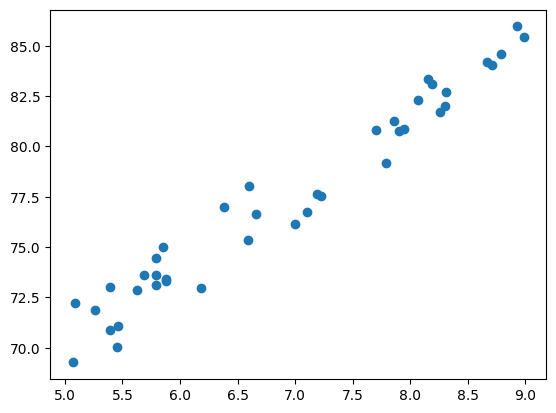

In [54]:
plt.scatter(x_test,y_test)

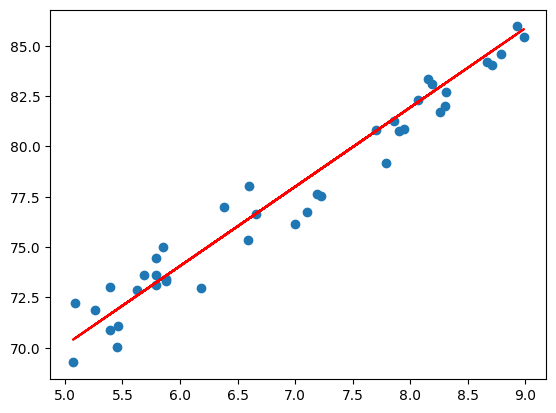

In [55]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred,color="red")


save ml model

In [57]:
import joblib
joblib.dump(lr,"student_mark_predictor_model.pkl")

['student_mark_predictor_model.pkl']

In [61]:
midel=joblib.load("student_mark_predictor_model.pkl")

In [62]:
midel.predict([[5]])[0][0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(70.12594512018406)

launch monitor and maintain your system